This is the first file to run

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
DATA_PATH = Path("../data/raw/2019 TestSet.xlsx")  # adjust if your structure differs
df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
print("Data types:\n", df.dtypes)

Shape: (93, 17)
Data types:
 Year              int64
Index No.           str
FinalGPA        float64
S1              float64
S2              float64
S3              float64
S4              float64
S5              float64
S6              float64
S7              float64
S8              float64
Department          str
Zscore          float64
Gender              str
EnglishMarks    float64
District            str
MediumAL            str
dtype: object


In [3]:
df.head()

,Year,Index No.,FinalGPA,S1,S2,S3,S4,S5,S6,S7,S8,Department,Zscore,Gender,EnglishMarks,District,MediumAL
0,2019,196097G,2.70,2.95,3.65,2.53,2.77,2.40,2.28,2.27,2.73,BA,1.5703,M,36.0,Badulla,S
1,2019,196096D,3.50,3.54,3.84,3.25,3.53,3.48,3.35,3.74,3.35,BA,1.4366,F,49.0,Anuradhapura,S
2,2019,196095A,3.54,3.45,3.91,3.49,3.49,3.78,3.25,3.42,3.52,BA,1.5585,M,51.0,Matara,S
3,2019,196094U,3.62,3.24,3.86,3.42,3.63,3.50,3.56,3.82,3.89,BPM,1.6797,F,53.0,Matara,S
4,2019,196093P,3.92,3.95,4.09,3.94,3.59,4.00,3.85,4.01,3.92,BA,1.5478,M,68.0,Kandy,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          93 non-null     int64  
 1   Index No.     93 non-null     str    
 2   FinalGPA      93 non-null     float64
 3   S1            93 non-null     float64
 4   S2            93 non-null     float64
 5   S3            93 non-null     float64
 6   S4            93 non-null     float64
 7   S5            93 non-null     float64
 8   S6            93 non-null     float64
 9   S7            93 non-null     float64
 10  S8            93 non-null     float64
 11  Department    93 non-null     str    
 12  Zscore        93 non-null     float64
 13  Gender        93 non-null     str    
 14  EnglishMarks  92 non-null     float64
 15  District      93 non-null     str    
 16  MediumAL      93 non-null     str    
dtypes: float64(11), int64(1), str(5)
memory usage: 14.2 KB


In [5]:
df.isna().sum().sort_values(ascending=False)


EnglishMarks    1
Year            0
Index No.       0
S1              0
FinalGPA        0
S3              0
S4              0
S5              0
S2              0
S6              0
S7              0
Department      0
S8              0
Zscore          0
Gender          0
District        0
MediumAL        0
dtype: int64

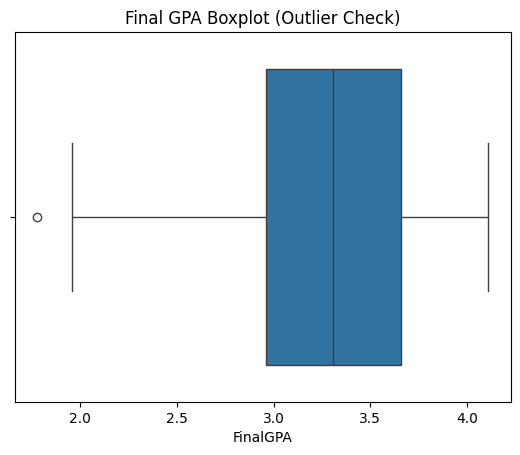

,Year,FinalGPA,S1,S2,S3,S4,S5,S6,S7,S8,Zscore,EnglishMarks
count,93.0,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,92.000000
mean,2019.0,3.273011,3.302903,3.590000,3.110430,3.296667,3.191935,3.057204,3.256129,3.366989,1.602768,51.706522
std,0.0,0.482324,0.460740,0.373485,0.590453,0.489124,0.581907,0.617612,0.738923,0.620282,0.209468,22.810513
min,2019.0,1.780000,2.250000,2.420000,1.610000,1.300000,0.830000,0.810000,0.400000,0.000000,1.041800,3.000000
25%,2019.0,2.960000,2.980000,3.390000,2.620000,2.990000,2.870000,2.750000,3.050000,3.080000,1.512100,32.000000
50%,2019.0,3.310000,3.320000,3.640000,3.180000,3.360000,3.280000,3.100000,3.480000,3.580000,1.581300,53.000000
75%,2019.0,3.660000,3.690000,3.860000,3.570000,3.640000,3.640000,3.510000,3.750000,3.750000,1.658900,69.500000
max,2019.0,4.110000,4.150000,4.130000,4.180000,4.090000,4.010000,4.060000,4.130000,4.130000,2.632000,90.000000


In [6]:
# print(df[["FinalGPA", "Zscore", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8","EnglishMarks"]].describe())

plt.figure()
sns.boxplot(x=df["FinalGPA"])
plt.title("Final GPA Boxplot (Outlier Check)")
plt.show()

df.describe()

In [7]:
def ClassCounts(FinalGPA):
    if FinalGPA <= 1.99:
        return "Fail"
    elif FinalGPA <= 2.99:
        return "Pass"
    elif FinalGPA <= 3.29:
        return "Second Lower"
    elif FinalGPA <= 3.69:
        return "Second Upper"
    else:
        return "High"

df["PerfGroup"] = df["FinalGPA"].apply(ClassCounts)
print(df["PerfGroup"].value_counts())

pd.crosstab(df["Year"], df["PerfGroup"])


PerfGroup
Second Upper    31
Pass            22
High            19
Second Lower    19
Fail             2
Name: count, dtype: int64


PerfGroup,Fail,High,Pass,Second Lower,Second Upper
Year,,,,,
2019,2,19,22,19,31


Based on above counts:
Pass and fail are underperforming
Second Lower is Average
Second upper and first class is Performing

In [8]:
def PerformanceGroupCounts(FinalGPA):
    if FinalGPA <= 2.00:
        return "Fail"
    elif FinalGPA <= 2.99:
        return "Pass"
    elif FinalGPA <= 3.29:
        return "Second Lower"
    elif FinalGPA <= 3.69:
        return "Second Upper"
    else:
        return "First class"

df["PerfGroup"] = df["FinalGPA"].apply(PerformanceGroupCounts)
print(df["PerfGroup"].value_counts())

PerfGroup
Second Upper    31
Pass            22
First class     19
Second Lower    19
Fail             2
Name: count, dtype: int64


In [9]:
def PerformanceGroupCounts(FinalGPA):
    if FinalGPA <= 2.99:
        return "Underperforming"
    elif FinalGPA <= 3.29:
        return "Average"
    else:
        return "Performing"

df["PerfGroup"] = df["FinalGPA"].apply(PerformanceGroupCounts)
print(df["PerfGroup"].value_counts())

PerfGroup
Performing         50
Underperforming    24
Average            19
Name: count, dtype: int64


In [10]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", cat_cols)

for c in cat_cols[1:]:
    print("\n")
    print(df[c].value_counts(dropna=False).head(20))

Categorical columns: ['Index No.', 'Department', 'Gender', 'District', 'MediumAL', 'PerfGroup']


Department
BA     50
BPM    31
FSM    12
Name: count, dtype: int64


Gender
F    58
M    35
Name: count, dtype: int64


District
Colombo         17
Gampaha         17
Kalutara        12
Galle            5
Anuradhapura     4
Kandy            4
Kurunegala       4
Ratnapura        4
Badulla          3
Matara           3
Jaffna           2
Kegalla          2
Matale           2
Batticaloa       2
Ampara           2
Nuwaraeliya      1
Hambantota       1
Puttalam         1
Vavuniya         1
Mannar           1
Name: count, dtype: int64


MediumAL
S    73
T    11
E     9
Name: count, dtype: int64


PerfGroup
Performing         50
Underperforming    24
Average            19
Name: count, dtype: int64


C:\Users\saw\AppData\Local\Temp\ipykernel_10200\3693009448.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [11]:
count = (df[[f"S{i}" for i in range(1,9)]] == 0).sum()
print('Count of zero values in each semester column:')
print(count)

Count of zero values in each semester column:
S1    0
S2    0
S3    0
S4    0
S5    0
S6    0
S7    0
S8    1
dtype: int64


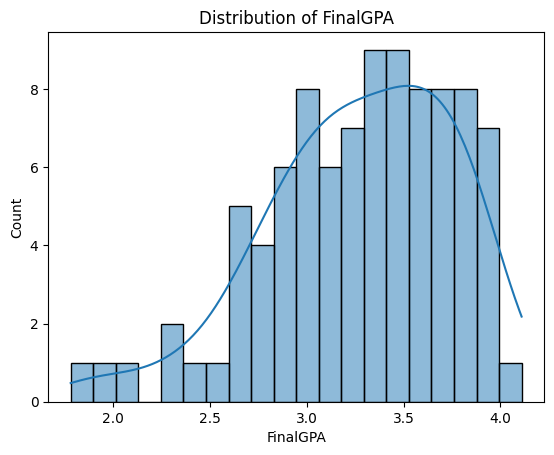

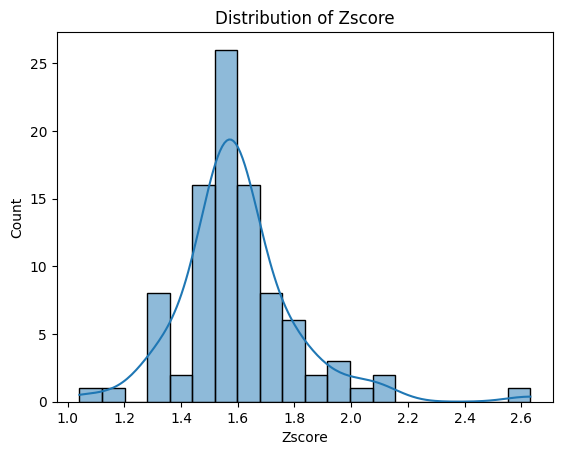

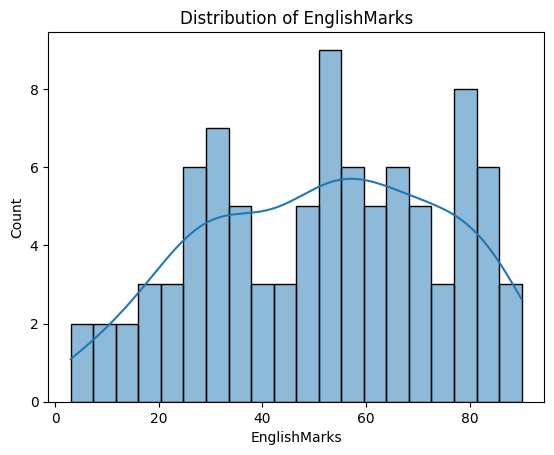

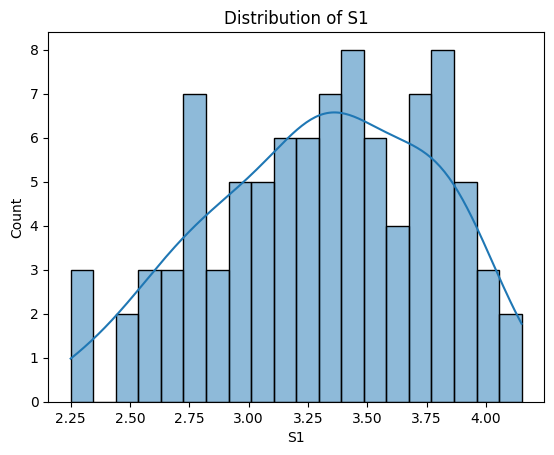

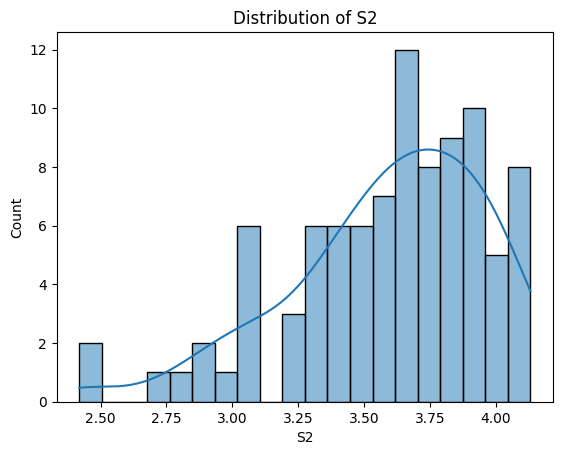

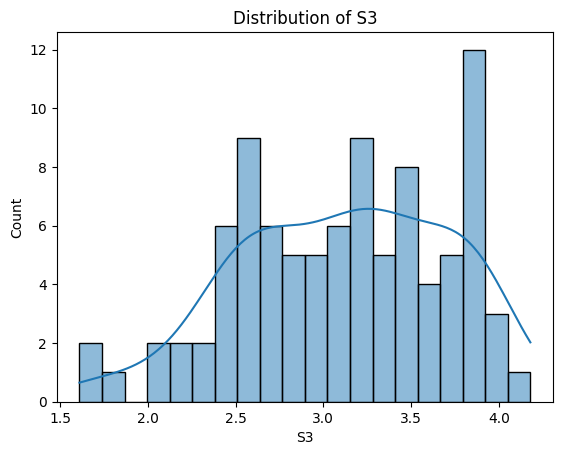

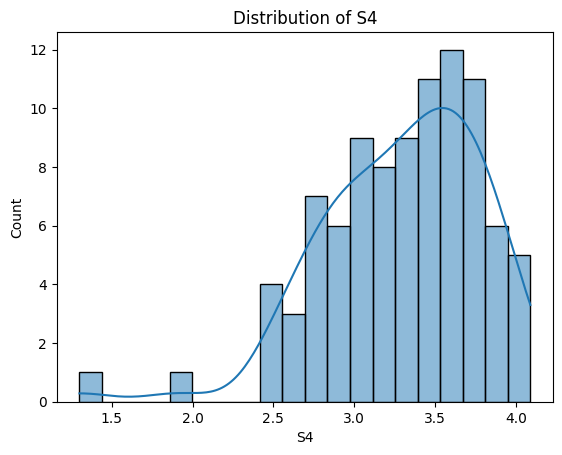

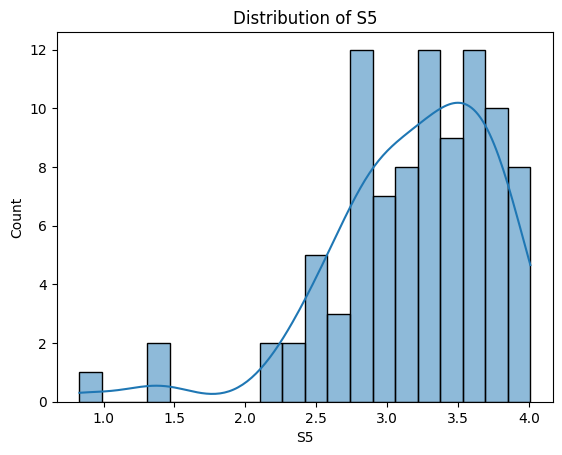

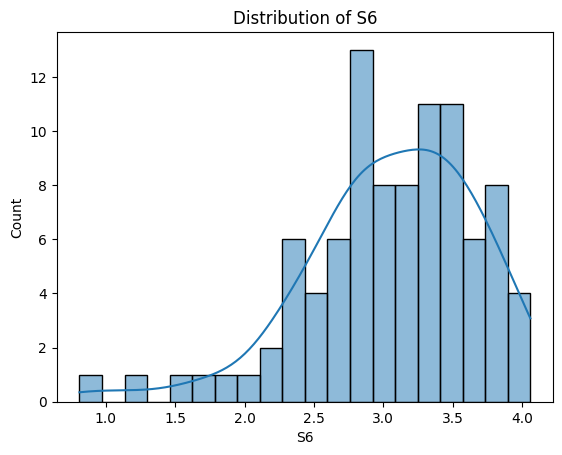

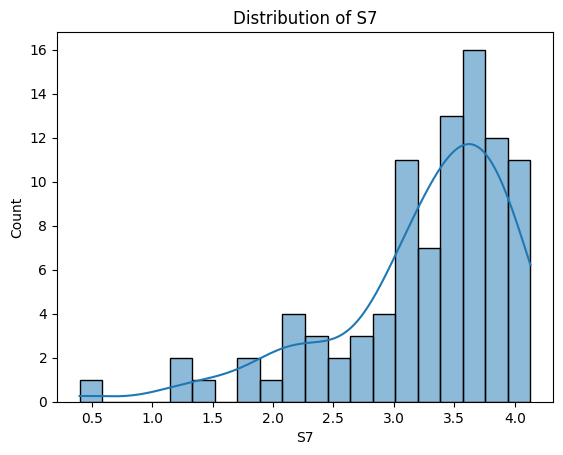

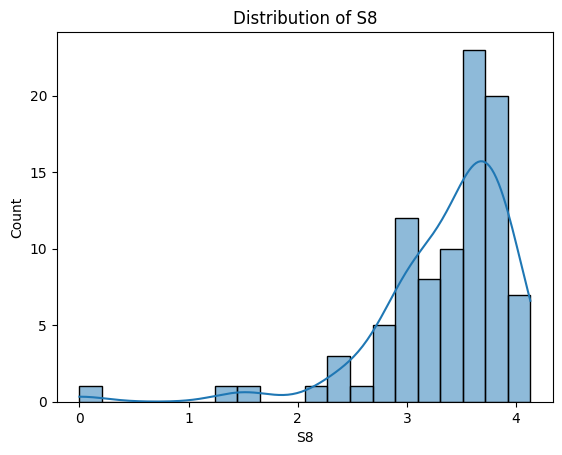

In [12]:
num_pre_cols = ["FinalGPA", "Zscore", "EnglishMarks","S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]

for col in num_pre_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

In [13]:
for col in num_pre_cols:
    print(col, df[col].skew())

FinalGPA -0.7175381100298333
Zscore 1.4188294627122089
EnglishMarks -0.1747235267607639
S1 -0.28035997903974735
S2 -0.9278709605748438
S3 -0.3182434688875024
S4 -0.9856764372165873
S5 -1.3506476635762894
S6 -0.9466668608582469
S7 -1.4607843315788347
S8 -2.4341134932696664


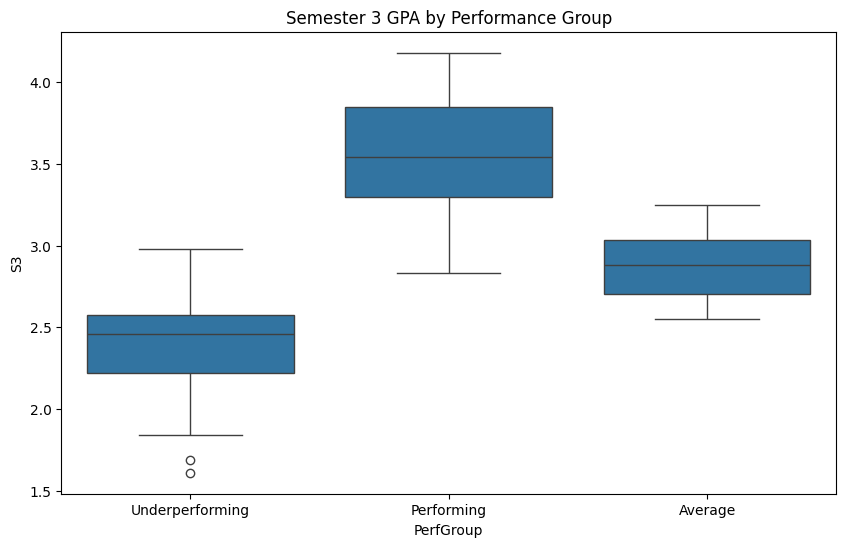

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S3"
)
plt.title("Semester 3 GPA by Performance Group")
plt.show()

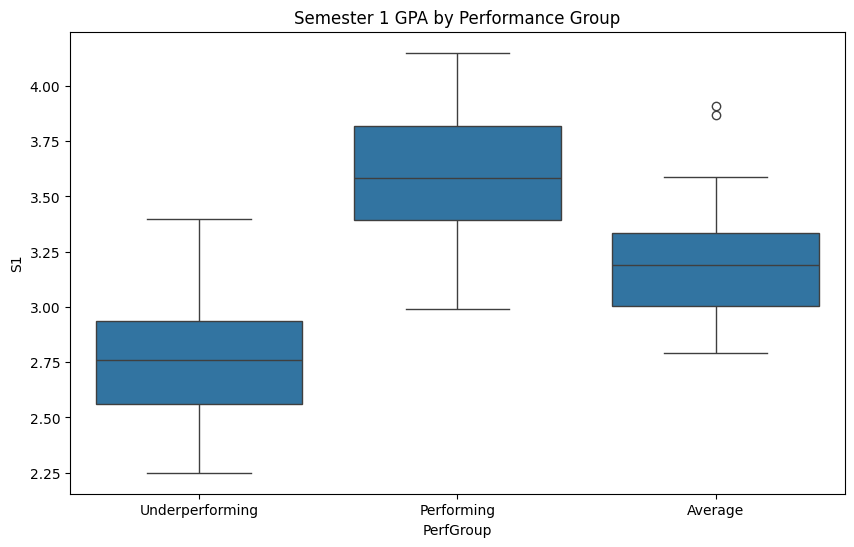

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S1"
)
plt.title("Semester 1 GPA by Performance Group")
plt.show()

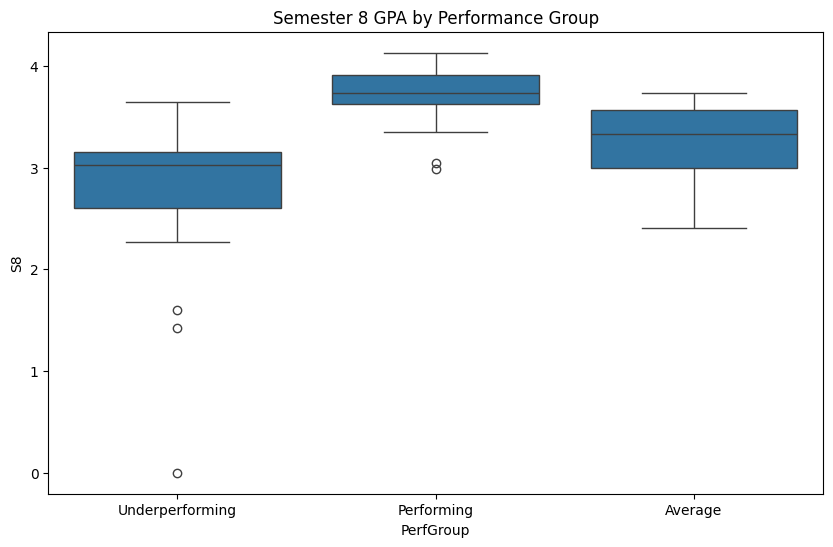

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S8"
)
plt.title("Semester 8 GPA by Performance Group")
plt.show()

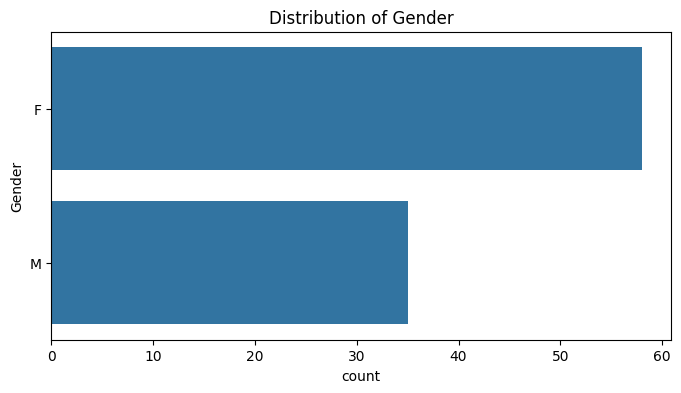

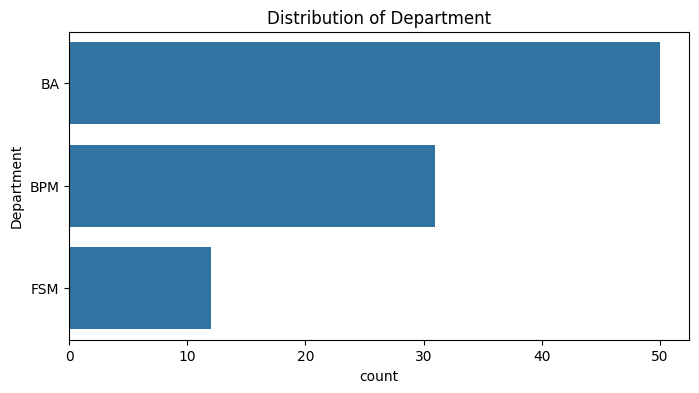

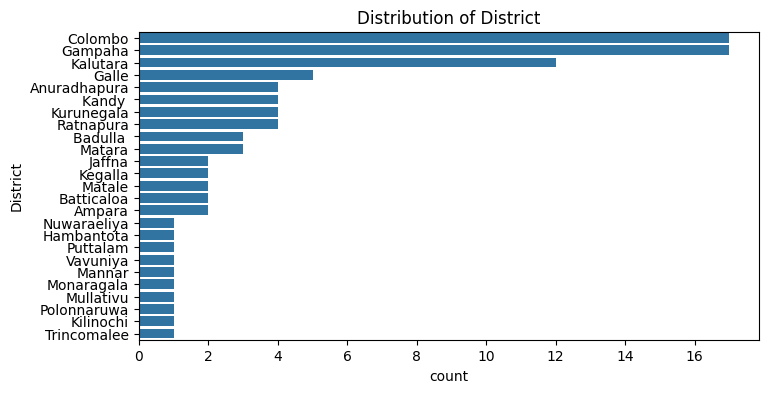

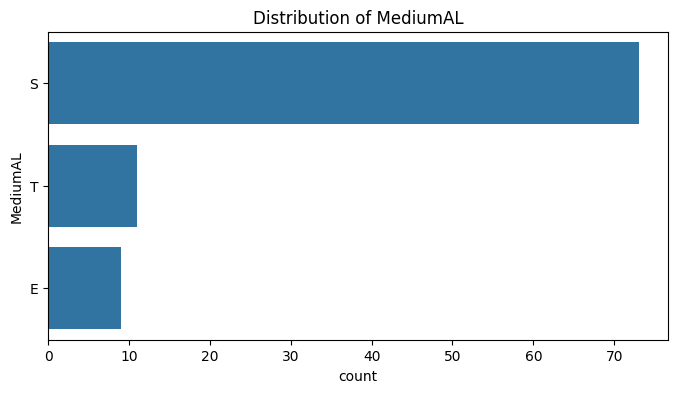

In [17]:
cat_cols = ["Gender", "Department", "District", "MediumAL"]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

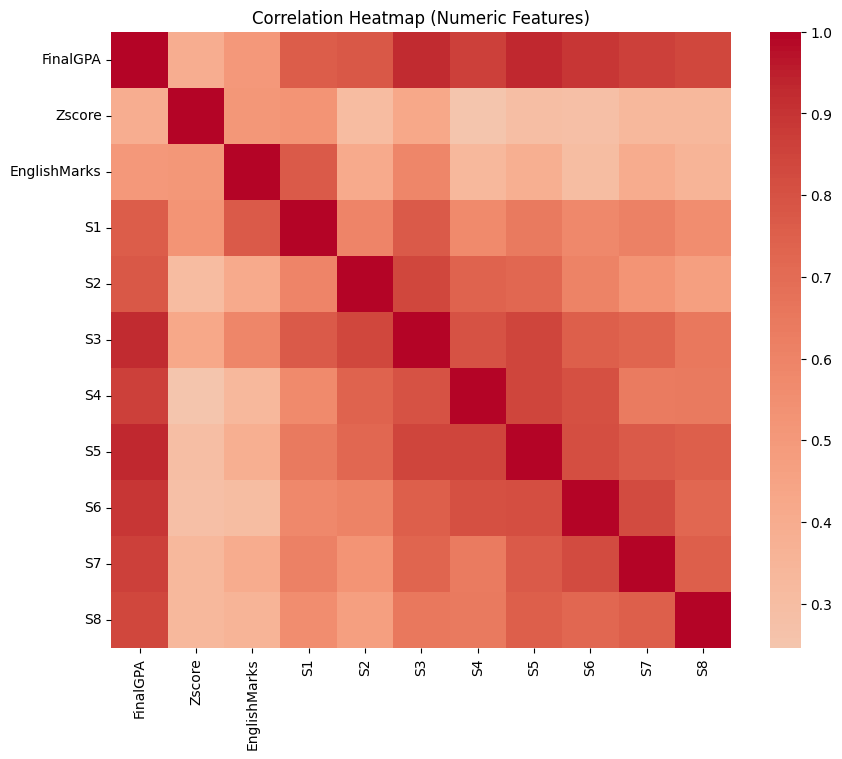

In [18]:
num_cols_for_corr = ["FinalGPA", "Zscore", "EnglishMarks", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]

plt.figure(figsize=(10,8))
sns.heatmap(
    df[num_cols_for_corr].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()